# Assignment 9 - Use an AI-based tool to generate simple video animations.

# **Model Used** -
**Stable Diffusion Img-2-Video**
# **APIs for Model Usage** -
**Huggingface Transformers and Diffusers Pipeline**


# **Model Details**

**Model Type**: Generative Video Model (Latent Video Diffusion).

**Developer**: Stability AI.

**Parameters**: Approximately 860 Million.

**Specialization (XT Version)**: This "XT" (Extended) version is fine-tuned to generate 25 frames, providing a longer and smoother animation (approx. 4 seconds) compared to the 14-frame base model.

**Primary Architecture**: It uses a Spatio-Temporal U-Net, which contains spatial layers to ensure image quality and temporal layers to ensure consistent motion across time.

**Operating Resolution**: Optimized for high-resolution widescreen output, specifically 1024x576 pixels.

**Core Libraries**: Built using the Diffusers and PyTorch ecosystems for efficient deployment on GPUs.

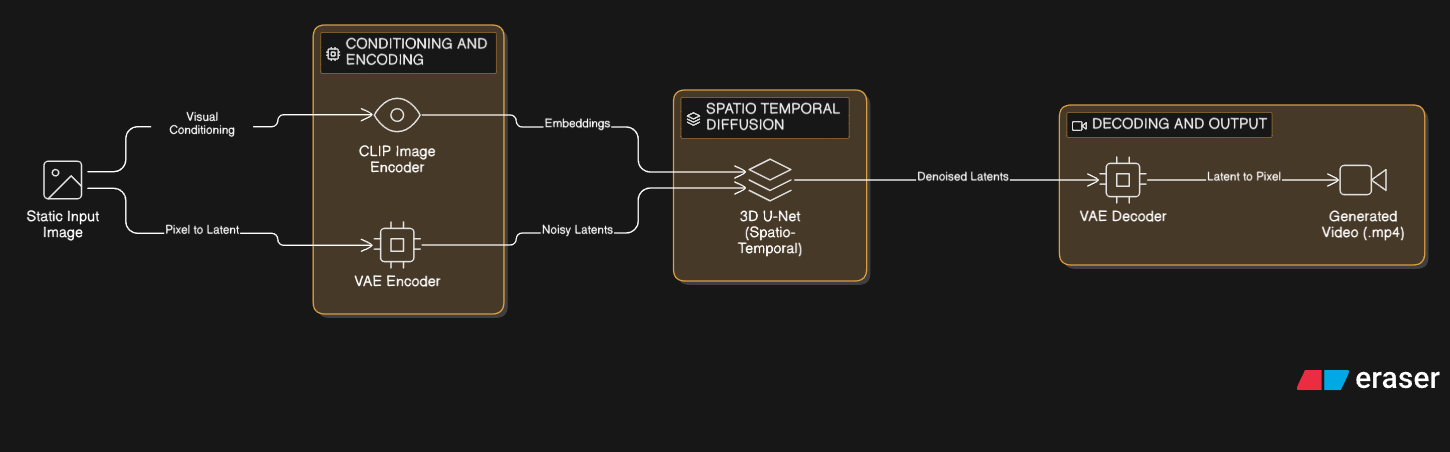

# **Architecture Breakdown**

**Step 1**: **Input Visual Conditioning**

    a) The model takes a static image as input.

    b) This image is processed by a CLIP Image Encoder to create embeddings that guide the visual style and content.

**Step 2**: **Latent Space Encoding**

    A VAE (Variational Autoencoder) compresses the image into a smaller "latent space."
    This allows the heavy computation to happen on smaller data representations rather than full-resolution pixels.

**Step 3**: **Spatio-Temporal 3D U-Net (The Core)**

    Unlike the standard Stable Diffusion (which only has spatial layers), SVD inserts Temporal Layers after every spatial layer.

    a) Spatial Layers: Handle the "look" of the individual frames (lines, textures, objects).

    b) Temporal Layers: Handle the "movement" and consistency between frames using 3D convolutions and temporal attention.

**Step 4**: **Decoding**

    Once the denoising loop is complete, the VAE Decoder expands the latent video back into visible pixel frames.
    SVD often uses a fine-tuned decoder to reduce flickering and ensure smooth motion.

# Why we chose this model?

| Feature	| SVD-XT (Stability AI)	| HunyuanVideo (Tencent)	| Mochi 1 (Genmo AI) |
|---------|---------------------|-------------------------|--------------------|
| Primary Focus	| High visual quality & fast iteration |	Long-form coherence & cinematic stability	| Controllability & stylistic range |
| Output Frames	| 25 Frames (XT Version) | 5-10 second clips (variable)	| Up to 163 frames (~5.4s) |
| Resolution | 1024x576 (or 576x1024)	| High (Cinematic)	| Capped at 480p |
| Model Parameters	| ~1.5 Billion |	8.3 Billion - 13 Billion |	10 Billion |
| Hardware Needs	| Moderate (Runs on Colab T4)	| Very High (VRAM intensive)	|Moderate/High |
| Best Use Case	| Product shots, concept art, loops |	Narrative continuity & scene evolution | Stylized art & designer exploration |

# **So What Stable Video Diffusion Does in Simple Words?**

## In Stable Video Diffusion, the model adds a "time" dimension. It has to ensure that the dog in Frame 1 still looks like the same dog in Frame 25, just with smooth movement.

# Learn more about Stable Diffusion
https://medium.com/@onkarmishra/stable-diffusion-explained-1f101284484d

---



# **Implementation Code**

# Step 1. Installing the necessary libraries

**diffusers** : The Lead Artist. This is the core library that knows the specific steps for turning a photo into a video.

**transformers**: The Brain. It helps the AI process and "understand" the visual data in your image.

**accelerate**: The Turbo Boost. It helps the AI run faster and manage your computer's memory so it doesn't crash.

**torch & torchvision**: The Engine & Eyes. PyTorch (torch) handles all the heavy math, while torchvision helps the AI "see" and process images.

**safetensors**: The Vault. A secure way to load the AI’s "brain" files (the weights) so they are safe and fast to open.

In [ ]:
!pip install diffusers transformers accelerate torch torchvision safetensors

# Step 2. Loading the pipeline using the diffusers library, powered by HuggingFace for multimodal, state-of-the-art image and video generation models.

In [ ]:
import torch
from diffusers import StableVideoDiffusionPipeline
from diffusers.utils import export_to_video

pipe = StableVideoDiffusionPipeline.from_pretrained(
    "stabilityai/stable-video-diffusion-img2vid-xt",
    torch_dtype=torch.float16  # memory-saving trick => Instead of using high-precision numbers, we use "half-precision," which makes the AI run much faster
)

pipe.enable_attention_slicing()   #tells the AI to process its "thoughts" in smaller chunks. It prevents the computer from getting overwhelmed and crashing when generating high-resolution video.
pipe.enable_model_cpu_offload()   #keeps only the part of the model currently "working" on the GPU and moves the rest to the CPU to save space


pipe.to("cuda")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components vae, image_encoder, unet, scheduler, feature_extractor to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.


StableVideoDiffusionPipeline {
  "_class_name": "StableVideoDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "stabilityai/stable-video-diffusion-img2vid-xt",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "EulerDiscreteScheduler"
  ],
  "unet": [
    "diffusers",
    "UNetSpatioTemporalConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKLTemporalDecoder"
  ]
}

# Step 3. Loading the image which is to be used as the conditional input.

In [ ]:
from PIL import Image  #We import a toolkit called Pillow. It is the standard industry tool for opening, manipulating, and saving images in Python.
import requests

image = Image.open("/content/pezibear-maltese-1123016_1920.jpg") #This tells the computer to find and open your specific photo (the Maltese dog).
.convert("RGB") #This ensures the image is in the standard "Red, Green, Blue" color format. This is important because AI models can get confused if they receive images with extra "hidden" layers (like transparency).
image = image.resize((1024, 576))

# Step 4. Clears unused cached GPU memory to reduce CUDA out-of-memory issues for use by PyTorch.

In [ ]:
import torch
torch.cuda.empty_cache()  # tells the computer to clear out any leftover, unused memory that PyTorch might be holding onto
torch.backends.cuda.matmul.allow_tf32 = True  # performance booster => allows the AI to use a special, faster way of doing math (TF32)

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  #It tells the computer to be flexible with how it hands out memory to the AI. Instead of grabbing one giant block of memory (which might fail), it allows the memory to grow and shrink as needed, preventing "Out of Memory" crashes.

# Step 5. Converting the image into moving frames using the diffusers pipeline

#Note:
## **decode_chunk_size** : This is one last memory-saving trick. Instead of trying to turn all 25 frames into pixels at the exact same time, the AI processes them in small "chunks" of 8. This keeps the computer's memory from overflowing while it builds the final images.

In [ ]:
frames = pipe(image, decode_chunk_size=8).frames[0]
export_to_video(frames, "generated.mp4", fps=7)

  0%|          | 0/25 [00:00<?, ?it/s]

'generated.mp4'